## Synthetic Item Bank Visualization

This notebook builds a synthetic item bank for two latent traits and produces three visualizations:

1. **Discrimination hyperplanes** â€” each item's decision boundary drawn as a chord through the unit circle; sensitive item lines are thicker (proportional to `sensitivity_level`).
2. **Angle histogram** â€” sanity-check that directions are spread approximately evenly over `[0Â°, 180Â°)`.
3. **Threshold locations** â€” all sensitive items (sorted by level) plus one non-sensitive reference, showing where each item partitions the projected score axis.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "synthetic.py").exists():
            return candidate
    raise RuntimeError("Could not find project root containing src/synthetic.py.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.synthetic import item_bank_to_dataframe, synthetic_item_bank
from src.plots import (
    apply_notebook_style, PALETTE,
    style_ax, format_axes,
    draw_question_arrow,
)

# Reusable global style for all notebook figures (fast, non-LaTeX rendering).
# Set use_tex=True only when you explicitly need full LaTeX text rendering.
apply_notebook_style()

print(f"Using project root: {PROJECT_ROOT}")


Using project root: C:\Users\49160\Adaptive-Onboarding


### Build a 2D Item Bank

In [2]:
bank = synthetic_item_bank(
    n_items=24,
    dim=2,
    n_categories=4,
    sensitive_fraction=0.30,
    rng_seed=1,
    vary_sensitivity_levels=True,
    angle_jitter=0.10,
    threshold_perturbation=0.08,
)

item_df = item_bank_to_dataframe(bank)
n_sensitive = int(item_df["is_sensitive"].sum())
print(f"Generated {len(item_df)} items: {n_sensitive} sensitive, {len(item_df) - n_sensitive} non-sensitive")
item_df[["item_id", "is_sensitive", "sensitivity_level", "angle", "a_0", "a_1"]].head()

Generated 24 items: 7 sensitive, 17 non-sensitive


,item_id,is_sensitive,sensitivity_level,angle,a_0,a_1
0,item_0000,False,0.000000,0.000155,1.000000,0.000155
1,item_0001,True,0.646442,0.136796,0.990658,0.136370
2,item_0002,False,0.000000,0.257141,0.967121,0.254317
3,item_0003,False,0.000000,0.398572,0.921616,0.388103
4,item_0004,False,0.000000,0.521136,0.867254,0.497865


### Discrimination Hyperplanes

Each line is the decision boundary (hyperplane) orthogonal to an item's discrimination vector `a`. Because all 2D directions live in the upper semicircle `[0, Ï€)`, the perpendicular hyperplanes cover the full circle. Sensitive item lines are thicker, with thickness proportional to `sensitivity_level`.

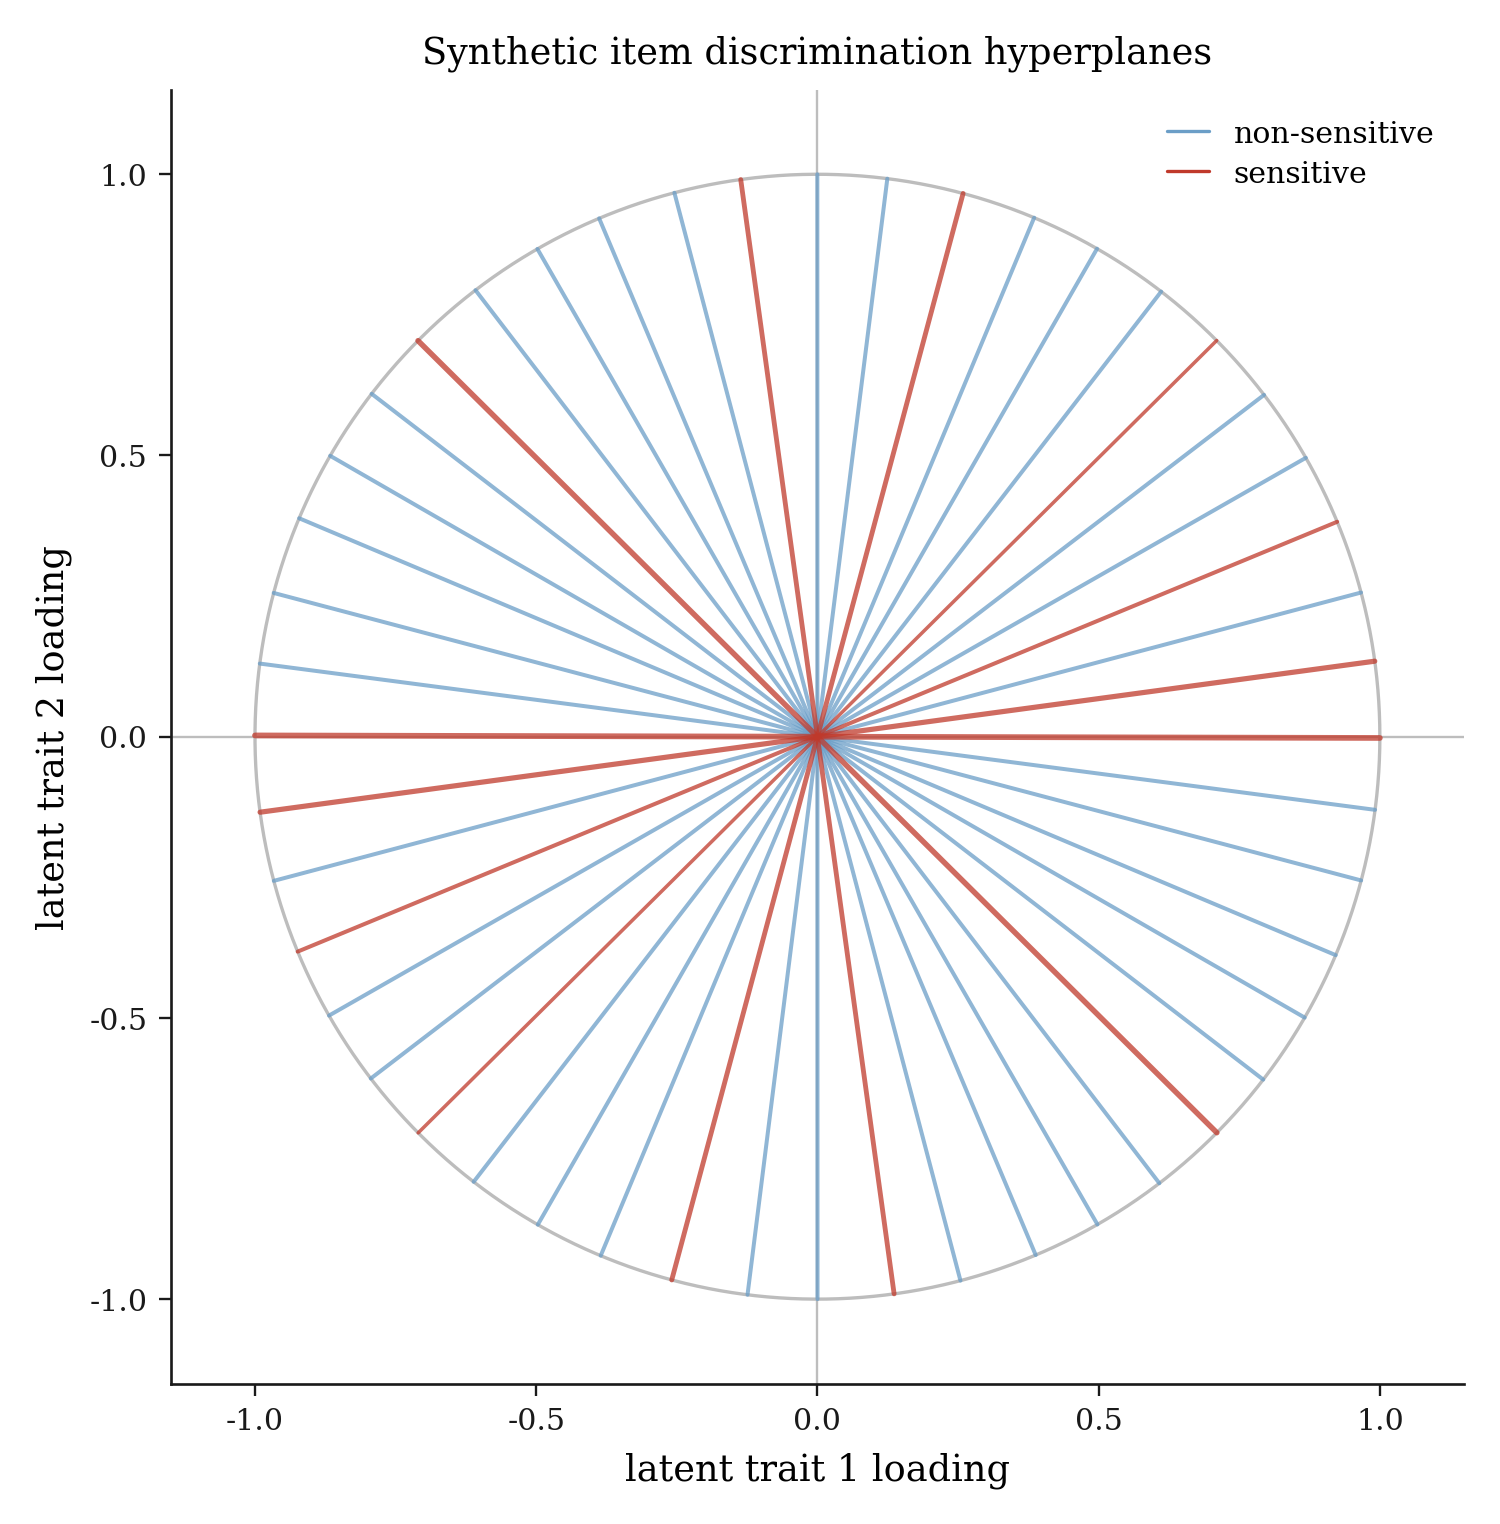

In [3]:
colors = {False: PALETTE["blue"], True: PALETTE["red"]}
labels = {False: "non-sensitive", True: "sensitive"}

fig, ax = plt.subplots(figsize=(7, 7))

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color=PALETTE["rule"], linewidth=1)

for is_sensitive in [False, True]:
    selected = [item for item in bank if item.is_sensitive is is_sensitive]
    for item in selected:
        a = item.a
        perp = np.array([-a[1], a[0]])  # unit vector perpendicular to a
        lw = 0.8 + 1.0 * item.sensitivity_level if item.is_sensitive else 1.2
        ax.plot(
            [-perp[0], perp[0]],
            [-perp[1], perp[1]],
            color=colors[is_sensitive],
            alpha=0.75,
            linewidth=lw,
            solid_capstyle="round",
        )
    ax.plot([], [], color=colors[is_sensitive], label=labels[is_sensitive], linewidth=1)

ax.axhline(0, color=PALETTE["rule"], linewidth=0.7, zorder=0)
ax.axvline(0, color=PALETTE["rule"], linewidth=0.7, zorder=0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_xlabel("latent trait 1 loading")
ax.set_ylabel("latent trait 2 loading")
ax.set_title("Synthetic item discrimination hyperplanes")
ax.legend(frameon=False)
plt.show()

### Distribution of Discrimination Angles

A quick sanity check that the generator spreads angles approximately evenly over `[0Â°, 180Â°)`.

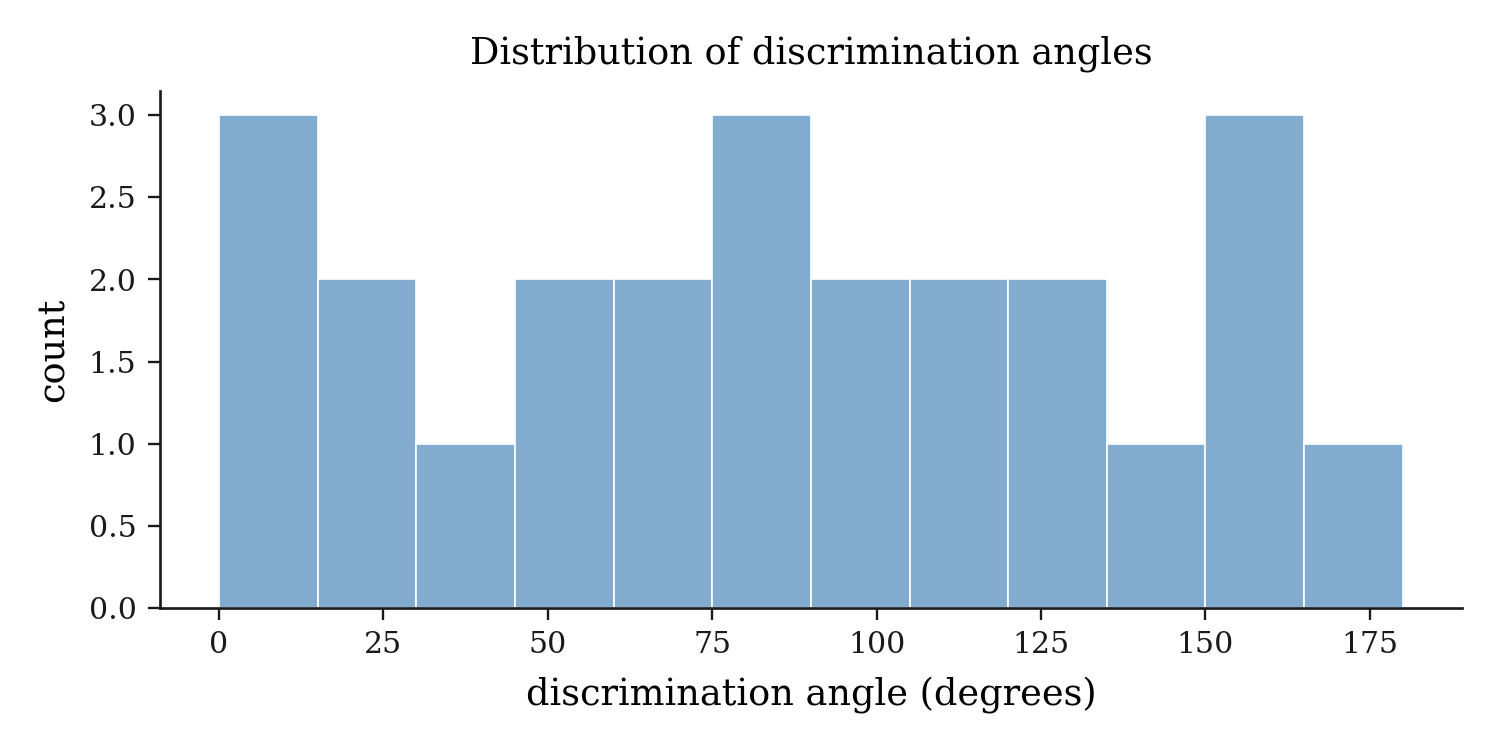

In [4]:
fig, ax = plt.subplots(figsize=(7, 2.8))

angles_deg = np.degrees(item_df["angle"].values)
ax.hist(
    angles_deg,
    bins=12,
    range=(0, 180),
    color=PALETTE["blue"],
    edgecolor="white",
    alpha=0.85,
)
ax.set_xlabel("discrimination angle (degrees)")
ax.set_ylabel("count")
ax.set_title("Distribution of discrimination angles")
style_ax(ax)
plt.show()

### One Item in Latent Coordinate Space

For one selected item, this plot shows:

- the discrimination vector `a` (arrow from the origin),
- the threshold-induced hyperplanes `a^T Î¸ = b_k` (parallel lines),
- and the corresponding normal directions.

This is the same geometry as the threshold view, but now shown directly in the latent coordinate system `(Î¸_1, Î¸_2)`.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


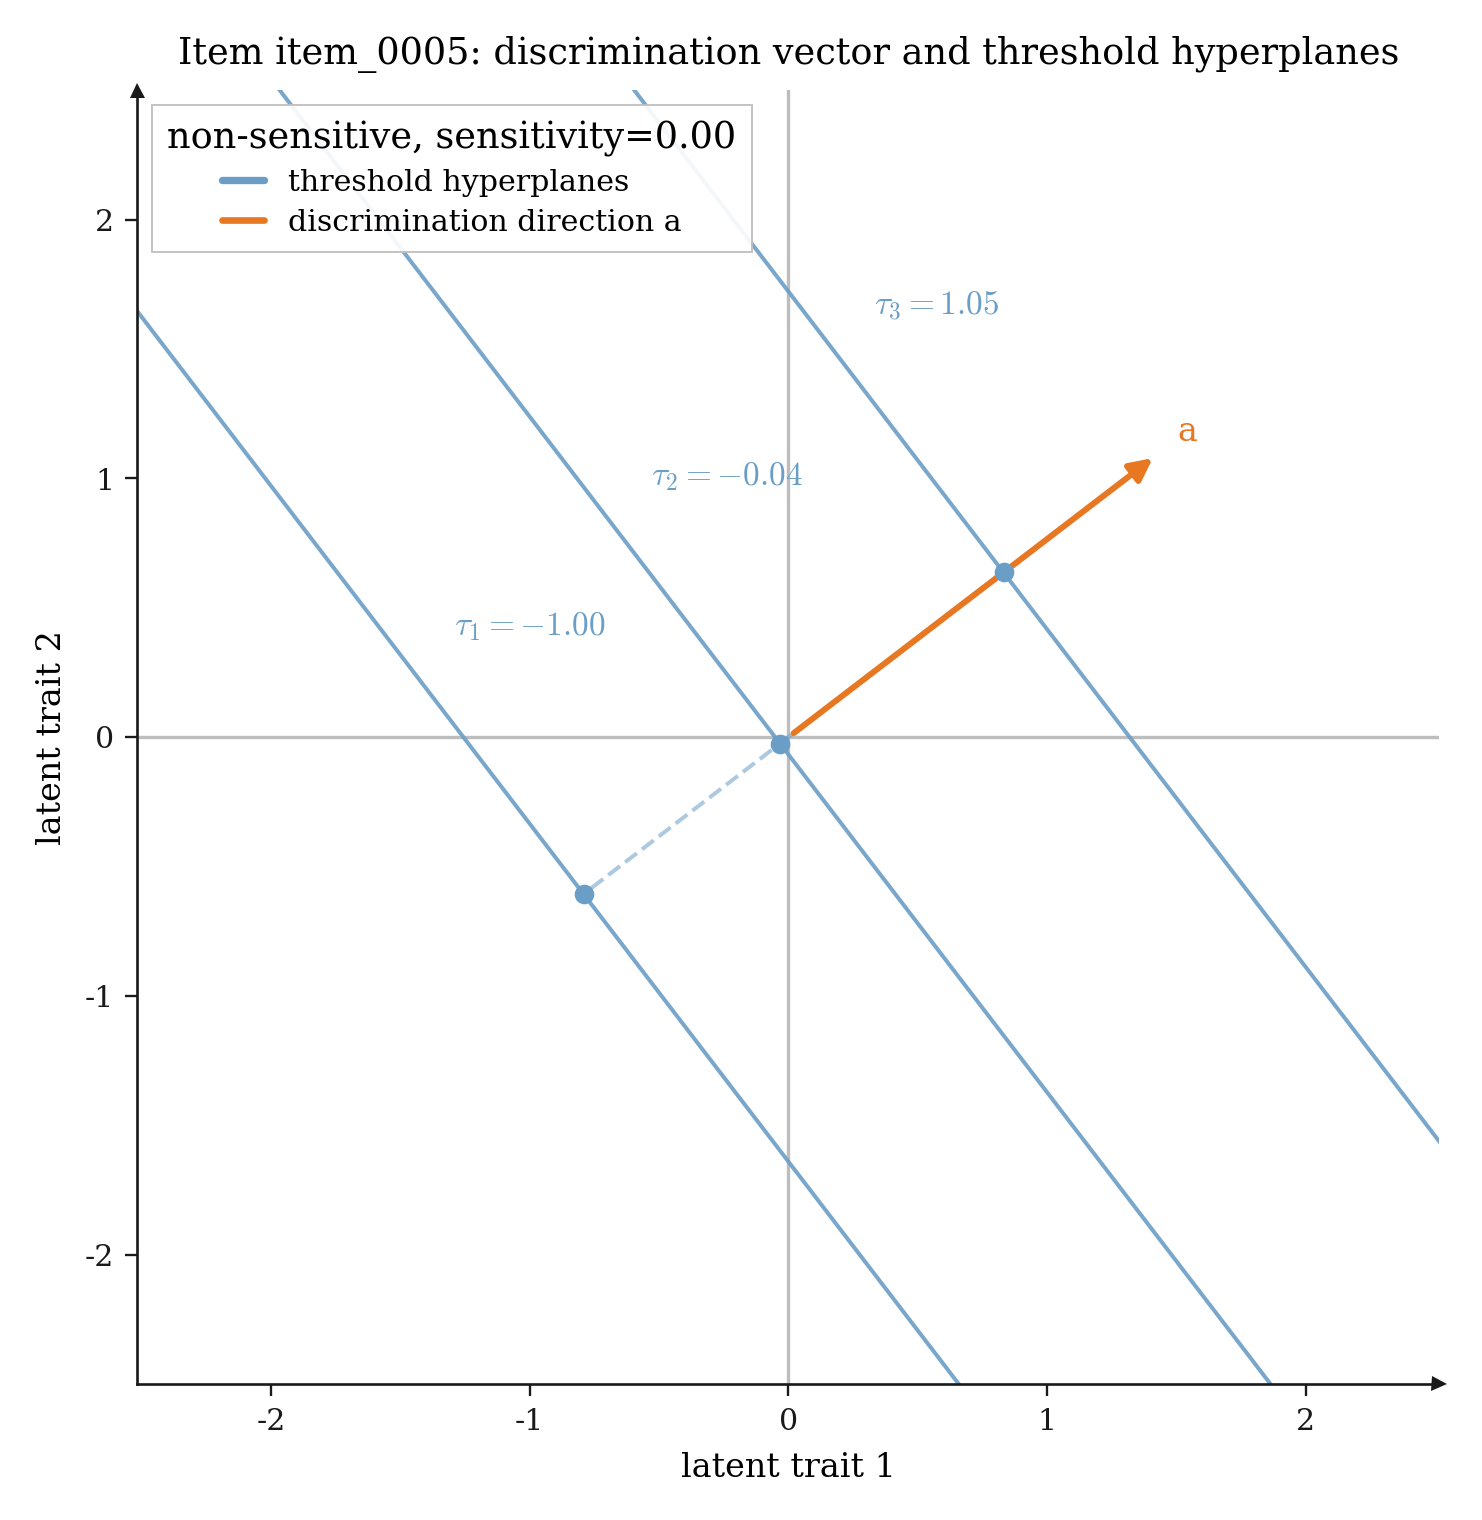

In [17]:
# Pick one item to visualize in latent coordinate space.
# Change this index to inspect another item's geometry.
item_index = 5
item = bank[item_index]

a = item.a.astype(float)
thresholds = item.thresholds.astype(float)
color = colors[item.is_sensitive]

# Unit normal vector for the hyperplanes and unit tangent direction along each line.
a_hat = a / np.linalg.norm(a)
t_hat = np.array([-a_hat[1], a_hat[0]])

# Plot extent in latent trait coordinates.
extent = 2.5
line_half_length = 4.0

fig, ax = plt.subplots(figsize=(7, 7))

# Draw coordinate axes.
ax.axhline(0.0, color=PALETTE["rule"], linewidth=1.0, zorder=0)
ax.axvline(0.0, color=PALETTE["rule"], linewidth=1.0, zorder=0)

# Draw the discrimination vector a from the origin.
draw_question_arrow(ax, origin=[0.0, 0.0], a=a_hat, scale=1.8, label="a")

# Draw threshold hyperplanes: a^T theta = b_k.
for k, b in enumerate(thresholds):
    center = b * a_hat
    p1 = center - line_half_length * t_hat
    p2 = center + line_half_length * t_hat
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=1.2, alpha=0.9)

    # Also draw a short normal segment to emphasize the offset along a.
    ax.plot([0.0, center[0]], [0.0, center[1]], color=color, linewidth=1.2, alpha=0.55, linestyle="--")
    ax.scatter([center[0]], [center[1]], color=color, s=28, zorder=5)
    ax.text(center[0]-0.5, center[1] + 1, f"$\\tau_{k+1}={b:.2f}$", color=color, fontsize=10)

ax.set_title(f"Item {item.item_id}: discrimination vector and threshold hyperplanes")
legend_label = f"{labels[item.is_sensitive]}, sensitivity={item.sensitivity_level:.2f}"
ax.plot([], [], color=color, linewidth=2.2, label="threshold hyperplanes")
ax.plot([], [], color=PALETTE["amber"], linewidth=2.0, label="discrimination direction a")
format_axes(ax, xlabel="latent trait 1", ylabel="latent trait 2",
            xlim=(-extent, extent), ylim=(-extent, extent))
ax.legend(loc="upper left", title=legend_label)
plt.show()

### Inspect High-Trait-Tail Sensitive Items

This section builds a second item bank with `sensitivity_assignment="high_trait_tail"`. An item receives a high score when it has strong positive loading on one of the selected sensitive axes and a high top threshold, meaning it probes the upper tail of that latent trait.

The mechanism for sensitivity assignment follows this:

positive_trait_loading = max(positive loading on selected sensitive axes)

top_threshold = highest response threshold

high_tail_score = positive_trait_loading * top_threshold



In [18]:
HIGH_TAIL_AXES = [1]  # use [0, 1] to inspect both axes in 2D

high_tail_bank = synthetic_item_bank(
    n_items=len(bank),
    dim=bank[0].dim,
    n_categories=bank[0].n_categories,
    sensitive_fraction=0.30,
    sensitivity_assignment="high_trait_tail",
    sensitive_axes=HIGH_TAIL_AXES,
    rng_seed=1,
    vary_sensitivity_levels=False,
    angle_jitter=0.10,
        threshold_perturbation=0.08,
)
high_tail_df = item_bank_to_dataframe(high_tail_bank)

axis_cols = [f"a_{axis}" for axis in HIGH_TAIL_AXES]
high_tail_df["positive_trait_loading"] = high_tail_df[axis_cols].clip(lower=0.0).max(axis=1)
high_tail_df["top_threshold"] = high_tail_df[[col for col in high_tail_df.columns if col.startswith("threshold_")]].max(axis=1)
high_tail_df["high_tail_score"] = high_tail_df["positive_trait_loading"] * high_tail_df["top_threshold"].clip(lower=1e-12)
high_tail_df["angle_deg"] = np.degrees(high_tail_df["angle"])

inspect_cols = [
    "item_id",
    "is_sensitive",
    "angle_deg",
    *axis_cols,
    "positive_trait_loading",
    "top_threshold",
    "high_tail_score",
]
high_tail_df.sort_values("high_tail_score", ascending=False)[inspect_cols].round(3).head(12)



,item_id,is_sensitive,angle_deg,a_1,positive_trait_loading,top_threshold,high_tail_score
10,item_0010,True,75.190,0.967,0.967,1.073,1.038
11,item_0011,True,82.529,0.992,0.992,0.975,0.967
13,item_0013,True,97.716,0.991,0.991,0.963,0.954
12,item_0012,True,89.872,1.000,1.000,0.921,0.921
15,item_0015,True,112.465,0.924,0.924,0.976,0.902
8,item_0008,True,60.037,0.866,0.866,1.026,0.889
16,item_0016,True,119.726,0.868,0.868,1.020,0.886
9,item_0009,False,67.146,0.921,0.921,0.960,0.885
14,item_0014,False,104.852,0.967,0.967,0.868,0.839
7,item_0007,False,52.432,0.793,0.793,0.959,0.761


The red points below are the items selected as sensitive by the high-trait-tail rule. The dashed rays show the selected sensitive axes.


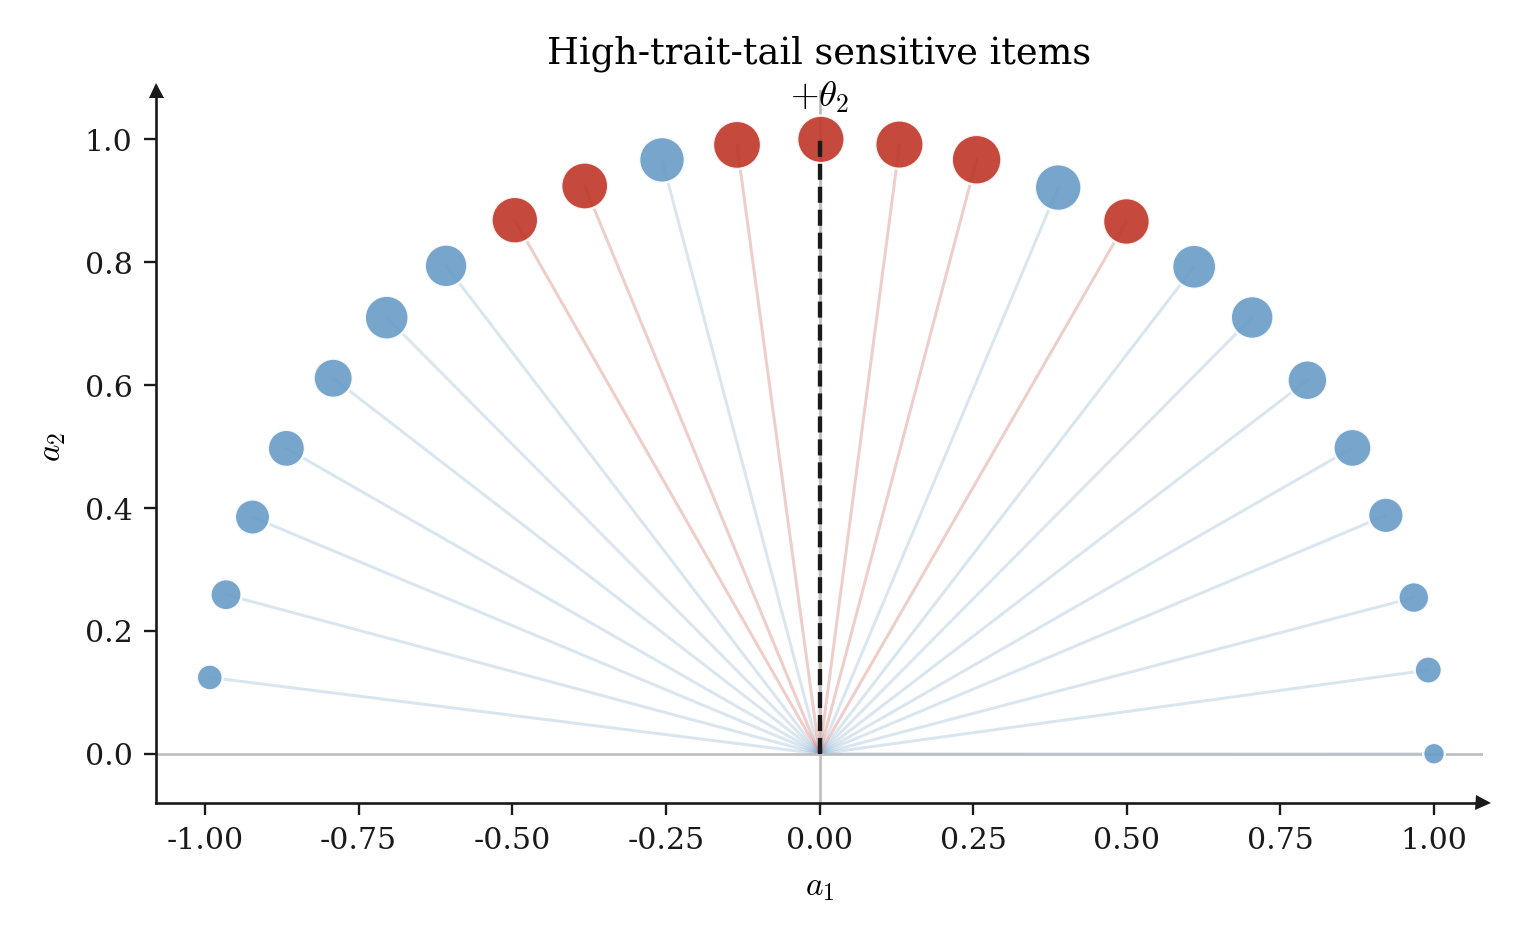

In [21]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))

point_colors = np.where(high_tail_df["is_sensitive"], PALETTE["red"], PALETTE["blue"])
sizes = 42 + 180 * (high_tail_df["high_tail_score"] / high_tail_df["high_tail_score"].max())
ax.scatter(
    high_tail_df["a_0"],
    high_tail_df["a_1"],
    s=sizes,
    color=point_colors,
    edgecolor="white",
    linewidth=0.7,
    alpha=0.92,
    zorder=3,
)
for row in high_tail_df.itertuples():
    ray_color = PALETTE["red"] if row.is_sensitive else PALETTE["blue"]
    ax.plot([0, row.a_0], [0, row.a_1], color=ray_color, alpha=0.25, linewidth=0.9, zorder=2)

for axis in HIGH_TAIL_AXES:
    endpoint = np.zeros(high_tail_bank[0].dim)
    endpoint[axis] = 1.0
    ax.plot([0, endpoint[0]], [0, endpoint[1]], color=PALETTE["ink"], linestyle="--", linewidth=1.3, zorder=4)
    ax.text(endpoint[0] * 1.07, endpoint[1] * 1.07, rf"$+\theta_{axis + 1}$", ha="center", va="center")

ax.axhline(0, color=PALETTE["rule"], linewidth=0.8)
ax.axvline(0, color=PALETTE["rule"], linewidth=0.8)
ax.plot([], [], marker="o", color=PALETTE["blue"], linestyle="none", label="normal item")
ax.plot([], [], marker="o", color=PALETTE["red"], linestyle="none", label="high-tail sensitive")
ax.set_title("High-trait-tail sensitive items")
format_axes(
    ax,
    xlabel=r"$a_1$",
    ylabel=r"$a_2$",
    xlim=(-1.08, 1.08),
    ylim=(-0.08, 1.08),
    legend_loc="lower left",
)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()





### Threshold Locations

The thresholds partition the projected score `a^T Î¸` into ordinal response categories. All items are shown in their original generation order (`item_0000`, `item_0001`, ...).

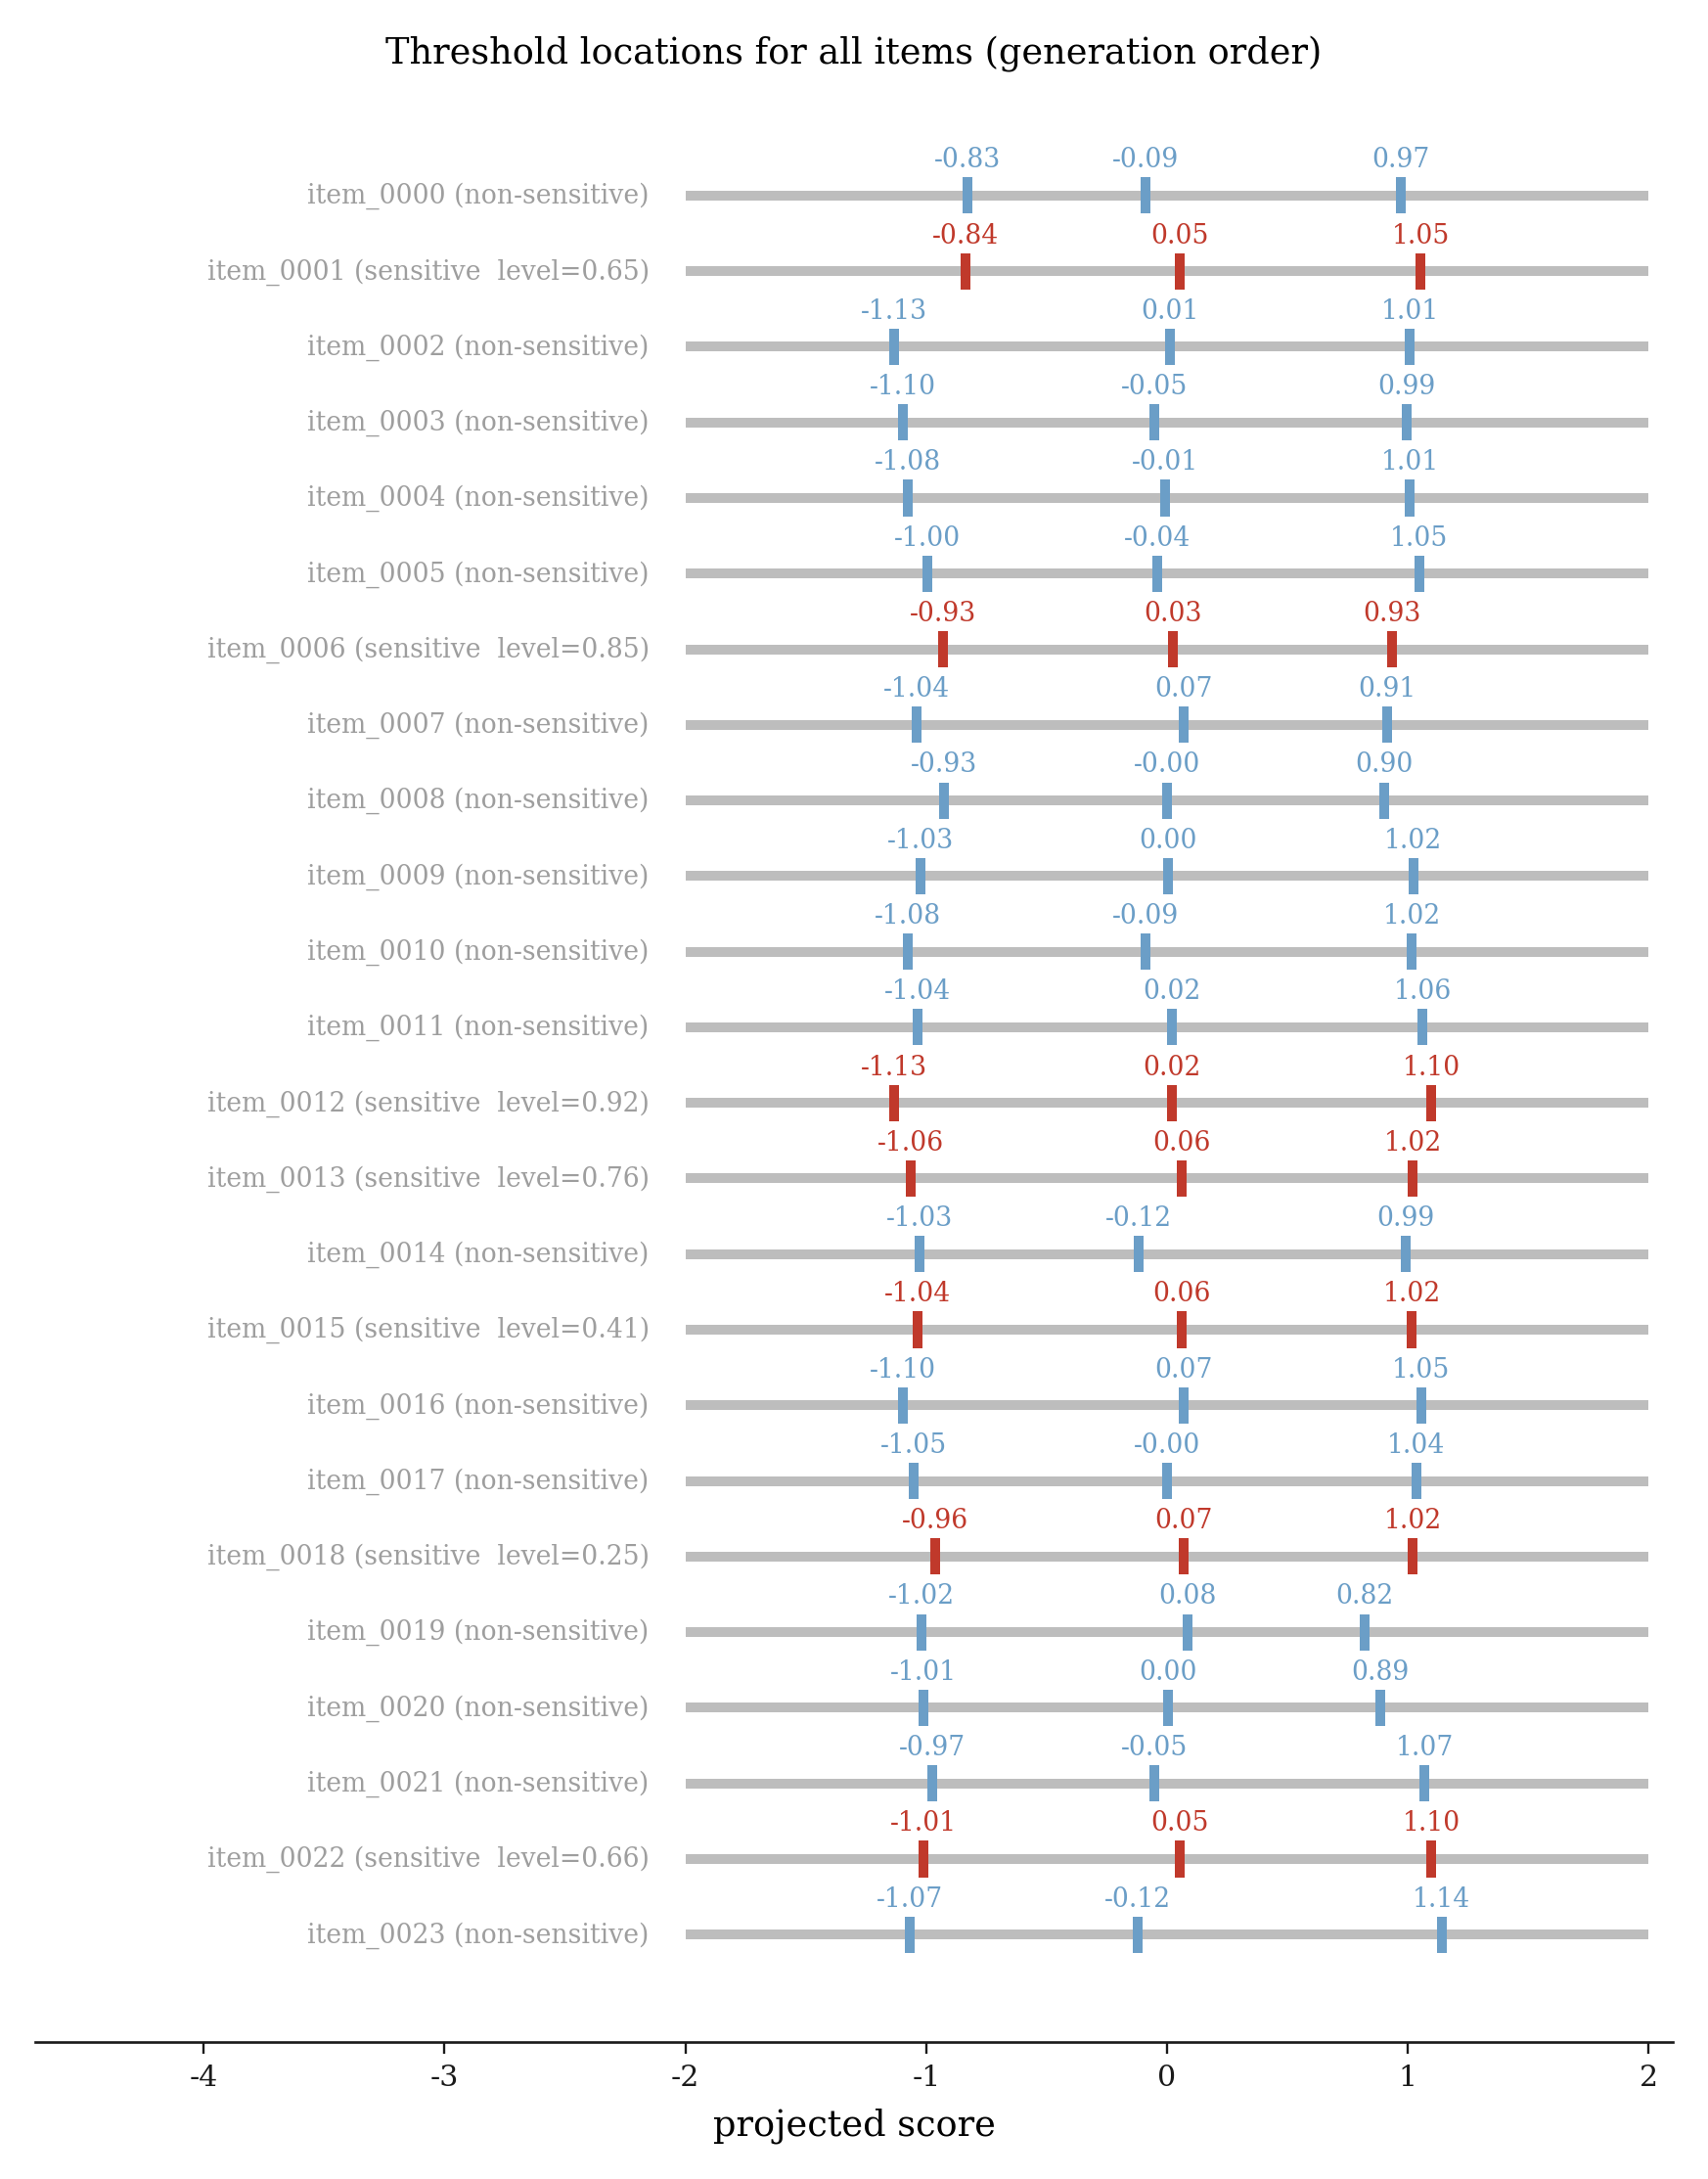

In [8]:
items_to_show = list(bank)  # preserves item generation order

x_min, x_max = -2.0, 2.0
n_rows = len(items_to_show)
fig, ax = plt.subplots(figsize=(9, max(2.8, 0.45 * n_rows)))

for row, item in enumerate(items_to_show):
    y = n_rows - row
    color = colors[item.is_sensitive]
    ax.hlines(y, x_min, x_max, color=PALETTE["rule"], linewidth=3)
    for threshold in item.thresholds:
        ax.vlines(threshold, y - 0.24, y + 0.24, color=color, linewidth=3)
        ax.text(
            threshold, y + 0.30, f"{threshold:.2f}",
            ha="center", va="bottom", color=color, fontsize=8,
        )
    level_str = f"  level={item.sensitivity_level:.2f}" if item.is_sensitive else ""
    ax.text(
        x_min - 0.15, y,
        f"{item.item_id} ({labels[item.is_sensitive]}{level_str})",
        ha="right", va="center", fontsize=8, color=PALETTE["mist"],
    )

ax.set_yticks([])
ax.set_xlabel("projected score")
ax.set_title("Threshold locations for all items (generation order)")
ax.set_xlim(x_min - 2.7, x_max + 0.1)
style_ax(ax, despine_sides=("left", "right", "top"))
plt.show()